In [30]:
from dotenv import load_dotenv
from langsmith import traceable

In [31]:
load_dotenv()

True

In [32]:
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [33]:
! ollama ls

NAME                    ID              SIZE      MODIFIED    
llama3.1:8b             46e0c10c039e    4.9 GB    4 hours ago    
llama3.2:1b             baf6a787fdff    1.3 GB    4 days ago     
llama3.2:3b             a80c4f17acd5    2.0 GB    6 days ago     
qwen3-embedding:0.6b    ac6da0dfba84    639 MB    9 days ago     


In [34]:
llm = ChatOllama(model="llama3.1:8b")

In [35]:
loader = PyPDFLoader("mohit_kumhar_report.pdf")

In [36]:
docs = loader.load()

In [37]:
len(docs)

62

In [38]:
docs

[Document(metadata={'producer': 'www.smallpdf.com', 'creator': 'www.smallpdf.com', 'creationdate': 'D:20251219130019', 'moddate': 'D:20251219130019', 'source': 'mohit_kumhar_report.pdf', 'total_pages': 62, 'page': 0, 'page_label': '1'}, page_content='An\nIndustrialTrainingReport\non\nAI-AgentstoEmpowerSRE–AIEngineering\nsubmitted\nin partial fulfilment\nfor the award of the degree of\nBachelorofTechnology\nIn\nComputerScienceandEngineering\nSubmittedTo:\nMr. Pawan Sen\nHOD\nComputer Science\nSubmittedBy:\nMohit Kumhar\n5th Sem. CSE\n23EACCS198\nDepartmentofComputerSciencefrom\nAryaCollegeofEngineering,Jaipur\nRajasthanTechnicalUniversity,Kota(2024–25)'),
 Document(metadata={'producer': 'www.smallpdf.com', 'creator': 'www.smallpdf.com', 'creationdate': 'D:20251219130019', 'moddate': 'D:20251219130019', 'source': 'mohit_kumhar_report.pdf', 'total_pages': 62, 'page': 1, 'page_label': '2'}, page_content='1\nAryaCollegeofEngineering\nSP-40,RIICOIndustrialArea,Jaipur(Raj)-302028\nDepartmento

In [39]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [40]:
chunks

[Document(metadata={'producer': 'www.smallpdf.com', 'creator': 'www.smallpdf.com', 'creationdate': 'D:20251219130019', 'moddate': 'D:20251219130019', 'source': 'mohit_kumhar_report.pdf', 'total_pages': 62, 'page': 0, 'page_label': '1'}, page_content='An\nIndustrialTrainingReport\non\nAI-AgentstoEmpowerSRE–AIEngineering\nsubmitted\nin partial fulfilment\nfor the award of the degree of\nBachelorofTechnology\nIn\nComputerScienceandEngineering\nSubmittedTo:\nMr. Pawan Sen\nHOD\nComputer Science\nSubmittedBy:\nMohit Kumhar\n5th Sem. CSE\n23EACCS198\nDepartmentofComputerSciencefrom\nAryaCollegeofEngineering,Jaipur\nRajasthanTechnicalUniversity,Kota(2024–25)'),
 Document(metadata={'producer': 'www.smallpdf.com', 'creator': 'www.smallpdf.com', 'creationdate': 'D:20251219130019', 'moddate': 'D:20251219130019', 'source': 'mohit_kumhar_report.pdf', 'total_pages': 62, 'page': 1, 'page_label': '2'}, page_content='1\nAryaCollegeofEngineering\nSP-40,RIICOIndustrialArea,Jaipur(Raj)-302028\nDepartmento

In [41]:
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")
vector_store = FAISS.from_documents(chunks, embeddings)

In [42]:
vector_store

In [43]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

In [44]:
retriever

VectorStoreRetriever(tags=['FAISS', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000014C355B7850>, search_kwargs={'k': 4})

In [45]:
@tool
# def rag_tool(query: str):
def rag_tool(query: str):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual/ conceptual questions
    that might be answered from the stored documents.
    """

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        "query": query,
        "context": context,
        "metadata": metadata
    }
    # return context
    # return {
    # "query": query,
    # "results": [
    #     {
    #         "content": doc.page_content,
    #         "metadata": doc.metadata
    #     }
    #     for doc in docs
    # ]
    # }
    

In [46]:
tools = [rag_tool]

In [47]:
llm_with_tool = llm.bind_tools(tools)

In [48]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [49]:
@traceable(name="chat_node")
def chat_node(state: ChatState):
    message = state['messages']
    response = llm_with_tool.invoke(message)

    return {"messages": [response]}

In [50]:
tool_node = ToolNode(tools)

In [51]:
graph = StateGraph(ChatState)

In [52]:
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [53]:
graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")
graph.add_edge("chat_node", END)

In [54]:
workflow = graph.compile()

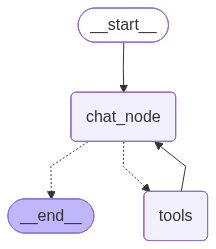

In [55]:
workflow

In [56]:
%%time
result = workflow.invoke(
    {
        "messages": [
            HumanMessage(content="how was the  experience of the internship")
        ]
    }
)

CPU times: total: 750 ms
Wall time: 54 s


In [57]:
result['messages'][-1].content

'The experience of the internship was highly productive and enriching. The intern, Mohit Kumhar, had the opportunity to work on Python-based backend development and intelligent agent systems at Nudgebee. He gained hands-on experience in working with intelligent agents and understanding their execution workflows in production. Mohit demonstrated strong technical skills, a self-motivated learning attitude, and successfully completed all assigned responsibilities.\n\nThe internship provided real-world exposure to industry-level software workflows, system reliability, and performance optimization. It enhanced Mohit\'s technical competence, strengthened his professional skills, and laid a strong foundation for his future career in intelligent systems and backend engineering.\n\nOverall, the experience was described as "remarkable" and "crucial," indicating that it had a significant impact on Mohit\'s learning and development as a software developer.'

In [58]:
result

{'messages': [HumanMessage(content='how was the  experience of the internship', additional_kwargs={}, response_metadata={}, id='0f060913-a69f-4347-b0cf-0e2dee230f8b'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-02-20T10:32:59.4716639Z', 'done': True, 'done_reason': 'stop', 'total_duration': 10448372000, 'load_duration': 7502565200, 'prompt_eval_count': 175, 'prompt_eval_duration': 679561600, 'eval_count': 20, 'eval_duration': 2241733000, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019c7a9b-fc7a-7673-9705-fcca1f2474cb-0', tool_calls=[{'name': 'rag_tool', 'args': {'query': 'experience of the internship'}, 'id': 'a200075e-c431-4764-ba15-eb13d400faff', 'type': 'tool_call'}], usage_metadata={'input_tokens': 175, 'output_tokens': 20, 'total_tokens': 195}),
  ToolMessage(content='{"query": "experience of the internship", "context": ["performance, and approach problem-solving in a stru